In [35]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import random 
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # stormeunice is not pip-installed in this kernel
import stormeunice as eun
import multiprocessing
import glob
from cmcrameri import cm
import metpy
from metpy.units import units
from matplotlib import gridspec
import matplotlib.transforms as mtransforms
import cartopy.crs as ccrs
from moarpalettes import get_palette

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

eun.style.set_style()
%matplotlib inline

random.seed(10)

# Preprocessing functions

In [36]:
# functions to convert accumulated variables to conventional ones

## accumulated variables & scaling factors
accumulated_vars = {'tp':60 * 60 * 24 * 1e3,'ttr':1,'tsr':1,'str':1,'ssr':1,'e':1}
accumulated_var_newunits = {'tp':'mm day$^{-1}$','ttr':'W m$^{-2}$','tsr':'W m$^{-2}$','str':'W m$^{-2}$','ssr':'W m$^{-2}$','e':'m s$^{-1}$'}

## definition to convert accumulated variables to instantaneous:
def accum2rate(ds):
    ds = ds.copy()
    oindex = ds.time
    inidate = pd.to_datetime(oindex[0].values)
    
    ds = ds.diff('time') / ( ds.time.diff('time').astype(float) / 1e9 )
    ds = ds.reindex(time=oindex)
    return ds[1:]

In [37]:
def preproc_ds(ds):
    
    ds = ds.copy().squeeze()
    
    fname = ds.encoding['source'].split('/')[-1].split('.')[0]
    
    expver = fname.split('_')[0]
    ds = ds.expand_dims({'experiment':[expver]})
    
    # set up aux data
    inidate = pd.to_datetime(ds.time[0].values)
    
    # expand dimensions to include extra info
    if not 'hDate' in ds:
        ds = ds.expand_dims({'inidate':[inidate]})
        
    if not 'number' in ds:
        ds = ds.expand_dims({'number':[0]})
        
    # put time dimension at front
    ds = ds.transpose('time',...)
    
    # convert accumulated variables into instantaneous
    for var,sf in accumulated_vars.items():
        if var in ds.keys():
            ds[var][1:] = accum2rate(ds[var]) * sf
            # set first value to equal zero [since it should be zero... but isn't always]
            ds[var][0] = 0
            ds[var].attrs['units'] = accumulated_var_newunits[var]
            
    return ds

In [38]:
def import_medr_tracks_TE(fpath):
    
    df = pd.read_csv(fpath,skipinitialspace=True)
    
    expdict = {'1':'ENS','b2nn':'pi','b2nq':'pi','b2ns':'pi','b2no':'incr','b2nr':'incr','b2nt':'incr'}
    
    fname = fpath.split('/')[-1]
    _,expid,inidate,mem = fname.split('_')
    
    df['expid'] = expid
    df['experiment'] = expdict[expid]
    df['inidate'] = pd.to_datetime(inidate)
    df['number'] = int(mem)
    
    return df

# Forecast and ERA5 data

In [39]:
# import ensemble forecast data
dir_eps = '/gf3/predict2/AWH012_LEACH_NASTORM/DATA/MED-R/ENS/EU025/sfc/*/*.nc'
eps = xr.open_mfdataset(dir_eps,preprocess=preproc_ds)
eps_GUST = eps.fg10.sel(latitude=slice(61,49),longitude=slice(-11,2)).resample(time='1d').max().load()

# directory for ERA5
era5_2022 = xr.open_dataset('/gf3/predict2/AWH012_LEACH_NASTORM/DATA/ERA5/EU025/sfc/2022.nc')
era5_GUST = era5_2022.fg10.sel(time=slice('2022-02-07','2022-02-22'),latitude=slice(61,49),longitude=slice(-11,2)).resample(time='1d').max().load()


/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ... 

# Tracks

In [40]:
# ERA5
era_track = pd.read_csv('/home/l/leach/Attribution/NA-Storms/Nick/Scripts/tracking/TE/TEStitch_2022_0',skipinitialspace=True)

In [41]:
P1 = multiprocessing.Pool(40)

ifs_tracks = P1.map(import_medr_tracks_TE, glob.glob('/home/l/leach/Attribution/NA-Storms/Nick/Scripts/tracking/TE/TEStitch_[!2]*'))

P1.close()

ifs_tracks = pd.concat(ifs_tracks)
ifs_tracks['date'] = pd.to_datetime(ifs_tracks.loc[:,['year','month','day','hour']])

## add era track in
era_track = pd.read_csv('/home/l/leach/Attribution/NA-Storms/Nick/Scripts/tracking/TE/TEStitch_2022_0',skipinitialspace=True)

era_track['expid'] = 'era5'
era_track['experiment'] = 'era5'
era_track['inidate'] = pd.to_datetime('2022-01-01')
era_track['number'] = 0
era_track['date'] = pd.to_datetime(era_track.loc[:,['year','month','day','hour']])

all_tracks = pd.concat([ifs_tracks,era_track])

eunice_track = era_track.query('track_id==5')

In [42]:
ifs_tracks_filter = ifs_tracks.groupby(['track_id','inidate','experiment','number']).agg(dict(date = min, day=np.size, lon = lambda x: x.iloc[0], lat = lambda x: x.iloc[0], msl = min))
eunice_filter = eunice_track.groupby(['track_id','inidate','experiment','number']).agg(dict(date = min, day=np.size, lon = lambda x: x.iloc[0], lat = lambda x: x.iloc[0], msl = min)).iloc[0]


In [43]:
## starttime criterion - must be detected within 12 hours (before or after) the ERA5 track detectino time
starttime_crit = (ifs_tracks_filter.date - eunice_filter.date).dt.total_seconds().abs()<(12*60*60)
## starting location criterion - must start within 10 degrees of the ERA5 track starting point
startloc_crit = np.sqrt((ifs_tracks_filter.lon-eunice_filter.lon)**2+(ifs_tracks_filter.lat-eunice_filter.lat)**2)<10
## depth criterion - must reach a depth of at least 980 hPa
minmsl_crit = ifs_tracks_filter.msl < 98000

ifs_tracks_filtered = ifs_tracks_filter.loc[starttime_crit&startloc_crit&minmsl_crit]

In [44]:
ifs_eunice_list = ifs_tracks.set_index(['track_id','inidate','experiment','number']).sort_index().loc[ifs_tracks_filtered.index].reset_index()
multi_track_members = ifs_eunice_list.groupby(['inidate','experiment','number','track_id']).agg(dict(year = lambda x: 1)).groupby(['inidate','experiment','number']).count().query('year > 1')

In [45]:
def eunice_dist(df):
    
    eunice_lons = eunice_track.lon.values
    eunice_lats = eunice_track.lat.values
    
    track_lons = df.lon.values
    track_lats = df.lat.values
    
    minsize = min(eunice_lons.size,track_lons.size)
    
    return np.sqrt((track_lons[:minsize]-eunice_lons[:minsize])**2+(track_lats[:minsize]-eunice_lats[:minsize])**2).sum()

In [46]:
for idx in multi_track_members.index:
    
    track_dists = ifs_eunice_list.query('inidate=="{}" & experiment=="{}" & number=={}'.format(*idx)).groupby('track_id').apply(eunice_dist)
    
    num_reject = track_dists.idxmax()
    
    ifs_eunice_list_idx = ifs_eunice_list.query('inidate=="{}" & experiment=="{}" & number=={} & track_id=={}'.format(*idx,num_reject)).index
    
    ifs_eunice_list = ifs_eunice_list.drop(ifs_eunice_list_idx)

# Observational data -- MIDAS

In [47]:
MIDAS_station_info = pd.read_csv('/gf3/predict2/AWH012_LEACH_NASTORM/DATA/MIDAS/MIDAS_station_info.csv',index_col=0)
MIDAS_station_info['Station_name'] = MIDAS_station_info.Station_name.str.split('\n',expand=True)[0].str.strip()

def get_MIDAS_stations_near(lat,lon,n=1):
    
    dlat = np.deg2rad(MIDAS_station_info.Latitude - lat)
    dlon = np.deg2rad(MIDAS_station_info.Longitude - lon)
    
    a = np.sin(dlat/2.0)**2 + np.cos(lat) * np.cos(MIDAS_station_info.Latitude) * np.sin(dlon/2.0)**2
    
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        D = np.arcsin(np.sqrt(a))
    
    return MIDAS_station_info.loc[D.sort_values().index[:n],'src_id'].values

In [48]:
MIDAS_2022 = pd.read_csv('/gf3/predict2/AWH012_LEACH_NASTORM/DATA/MIDAS/wind/midas_wind_202201-202212.txt',
            names=[x.strip() for x in pd.read_csv('https://dap.ceda.ac.uk/badc/ukmo-midas/metadata/table_structures/WMTB.txt',header=None).values.flatten()])

MIDAS_2022 = MIDAS_2022.apply(lambda x: x.replace(' ',np.nan).astype(float)*0.514444 if x.name[-5:]=='SPEED' else x)
MIDAS_2022['OB_END_TIME'] = pd.to_datetime(MIDAS_2022.OB_END_TIME)

/home/e/ermis/nobackups/miniforge3/envs/babet-3-7-12_new/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3552: DtypeWarning: Columns (19) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [49]:
MIDAS_2022_GUST = MIDAS_2022[['OB_END_TIME','SRC_ID','MAX_GUST_SPEED']]
MIDAS_2022_GUST = MIDAS_2022_GUST.groupby('SRC_ID').resample('1d',on='OB_END_TIME').max().dropna()
MIDAS_2022_GUST[['Latitude','Longitude']] = MIDAS_station_info.set_index('src_id').loc[MIDAS_2022_GUST.SRC_ID.astype(int),['Latitude','Longitude']].values

# Thesis plot

['figures/THESIS_track_and_gusts.png', 'figures/THESIS_track_and_gusts.pdf']

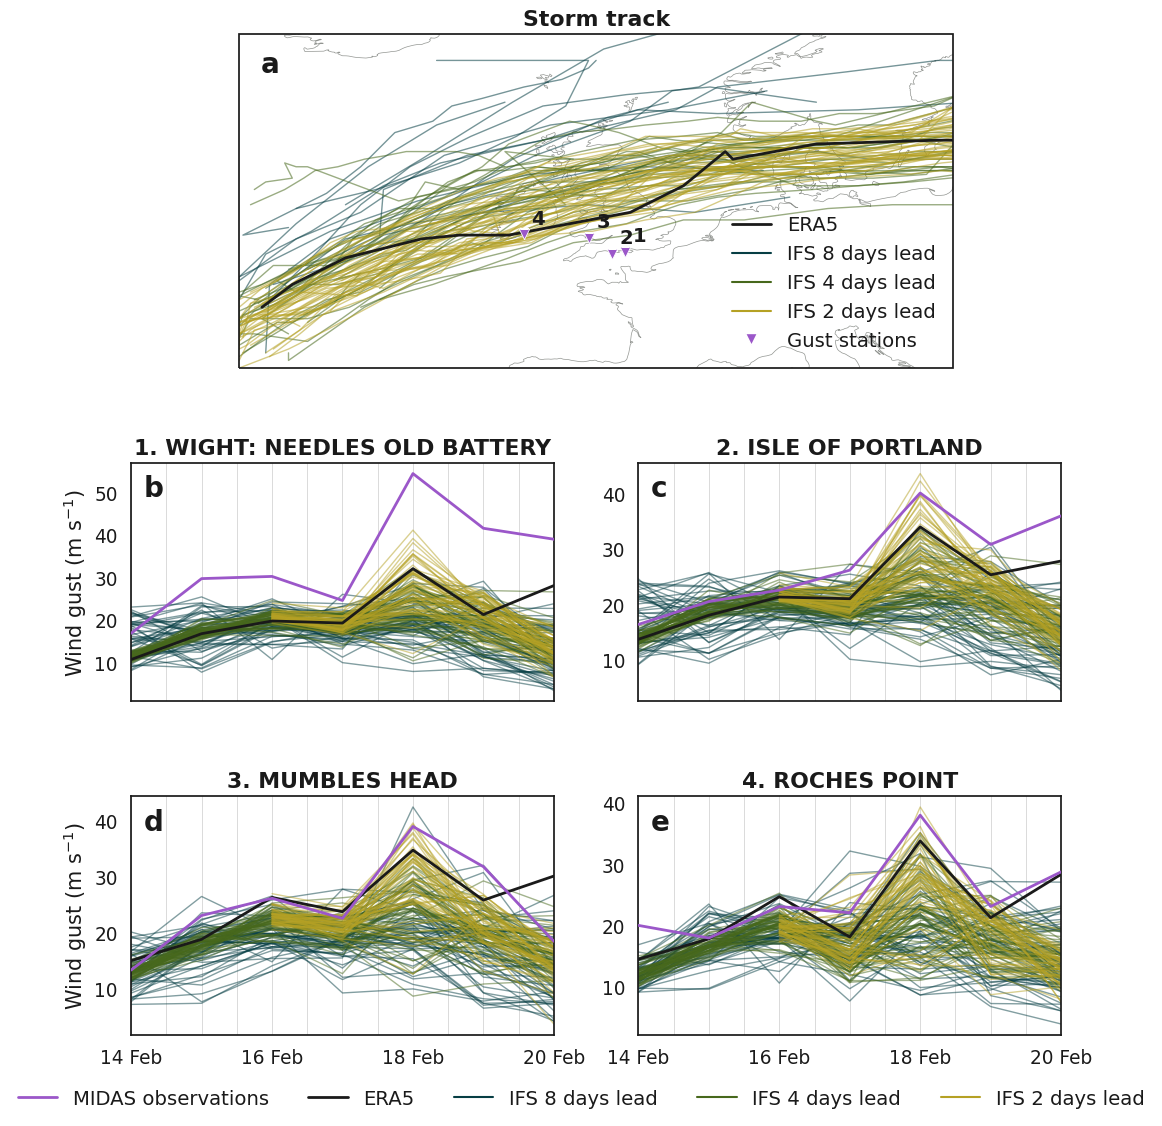

In [57]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

style = eun.style

# -- three EPS lead times (initialisation dates) shared between the track and gust plots
lead_times = ['2022-02-10', '2022-02-14', '2022-02-16']

# lead-time colours: the shared bamako ramp (style.RAMP), sampled over [0, 1]
# rather than indexed -- style.RAMP(n) would return the single colour at LUT
# index n. The ends are trimmed to keep every line legible on white.
_pal = style.RAMP(np.linspace(0.05, 0.75, len(lead_times)))
lt_colors = dict(zip(lead_times, _pal))

# ERA5 is the reference, so it takes ink; the MIDAS observations take the orchid
# accent, which style.py reserves for observations drawn over a model ensemble
# and keeps clear of the bamako ramp.
midas_color = style.accent('orchid')
# midas_color = '#8b8b8b'
era_color = style.INK

# -- pick the 4 stations with the largest observed gust on 18 Feb (peak of the storm)
station_max = MIDAS_2022_GUST.loc[(slice(None), '2022-02-18'), :].groupby(level=0).max()
top_stations = station_max.MAX_GUST_SPEED.sort_values().index[-4:][::-1]

# ---------------------------------------------------------------------------
# figure layout: track map on top (full width), 2x2 gust time series underneath
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(12, 13))
gs = fig.add_gridspec(3, 2, height_ratios=[1.4, 1, 1], hspace=0.35, wspace=0.2)

ax_map = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
axes_ts = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]),
           fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]

# type sizes are quoted at style.REF_WIDTH and scaled to this canvas, so they
# print at the same size as the rest of the figures once scaled to page width
fs_title = style.scaled(style.FS_TITLE, fig)
fs_label = style.scaled(style.FS_LABEL, fig)
fs_tick = style.scaled(style.FS_TICK, fig)
fs_annot = style.scaled(style.FS_ANNOT, fig)

# ---------------------------------------------------------------------------
# TOP: storm track in ERA5 overlaid with the EPS ensemble at three lead times
# ---------------------------------------------------------------------------
for lt in lead_times:
    sub = ifs_eunice_list[(ifs_eunice_list.experiment == 'ENS') &
                          (ifs_eunice_list.inidate == pd.Timestamp(lt))]
    for _, memb in sub.groupby('number'):
        ax_map.plot(memb.lon, memb.lat, color=lt_colors[lt], lw=1, alpha=0.55,
                    transform=ccrs.PlateCarree(), zorder=2)

# ERA5 (reanalysis) track on top
ax_map.plot(eunice_track.lon, eunice_track.lat, color=era_color, lw=2,
            transform=ccrs.PlateCarree(), zorder=4)

ax_map.coastlines(color='xkcd:grey', lw=0.5)
ax_map.set_extent([-27, 20, 43, 65], crs=ccrs.PlateCarree())

# locations of the stations used in the gust panels below, in the same orchid as
# their observations (numbered to match the panels)
station_coords = MIDAS_station_info.set_index('src_id').loc[top_stations, ['Latitude', 'Longitude']]
ax_map.scatter(station_coords.Longitude, station_coords.Latitude,
               marker='v', s=55, color=midas_color, edgecolor='w', linewidth=0.6,
               transform=ccrs.PlateCarree(), zorder=6)
for n, (sid, row) in enumerate(station_coords.iterrows(), start=1):
    ax_map.text(row.Longitude + 0.5, row.Latitude + 0.4, str(n), fontsize=fs_annot,
                fontweight='bold', ha='left', va='bottom', color=style.INK,
                transform=ccrs.PlateCarree(), zorder=7)

lead_time_labels = {'2022-02-10': '8', '2022-02-14': '4', '2022-02-16': '2'}
track_handles = [Line2D([], [], color=era_color, lw=2, label='ERA5')] + \
                [Line2D([], [], color=lt_colors[lt], lw=1.5,
                        label=f'IFS {lead_time_labels[lt]} days lead')
                 for lt in lead_times] + \
                [Line2D([], [], marker='v', color=midas_color, linestyle='none',
                        markeredgecolor='w', markersize=8, label='Gust stations')]
ax_map.legend(handles=track_handles, loc='lower right', frameon=False,
              fontsize=fs_annot)
ax_map.set_title('Storm track', fontweight='bold', fontsize=fs_title)

# ---------------------------------------------------------------------------
# BOTTOM: gust time series at the 4 peak-gust stations + EPS at the 3 lead times
# ---------------------------------------------------------------------------
ts_win = slice('2022-02-14', '2022-02-21')

for i, src_id in enumerate(top_stations):
    ax = axes_ts[i]
    s = MIDAS_station_info.set_index('src_id').loc[src_id]

    # ERA5 reanalysis gusts
    era_df = (era5_GUST.sel(latitude=s.Latitude, longitude=s.Longitude, method='nearest')
                       .to_dataframe().reset_index())
    ax.plot(era_df.time, era_df.fg10, color=era_color, lw=2, zorder=3)

    # observed station gusts (select the column before reset_index: OB_END_TIME is
    # both an index level and a column in MIDAS_2022_GUST)
    obs = MIDAS_2022_GUST.loc[(src_id, ts_win), :].MAX_GUST_SPEED.reset_index()
    ax.plot(obs.OB_END_TIME, obs.MAX_GUST_SPEED, color=midas_color, lw=2, zorder=4)

    # EPS ensemble gusts at each lead time, drawn last so they sit on top
    for lt in lead_times:
        try:
            eps_sel = (eps_GUST.sel(latitude=s.Latitude, longitude=s.Longitude,
                                    method='nearest')
                               .sel(inidate=pd.Timestamp(lt)))
        except KeyError:
            continue
        eps_df = eps_sel.to_dataframe().reset_index()
        for _, memb in eps_df.groupby('number'):
            ax.plot(memb.time, memb.fg10, color=lt_colors[lt], lw=1, alpha=0.5, zorder=2)

    ax.set_xlim(pd.Timestamp('2022-02-14 00'), pd.Timestamp('2022-02-20 00'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.set_title(f'{i + 1}. {s.Station_name}', fontweight='bold', fontsize=fs_title)
    ax.tick_params(labelsize=fs_tick)

    # add vertical lines for each day at 00:00 UTC
    for day in pd.date_range(start='2022-02-14 00:00', end='2022-02-21 00:00', freq='12H'):
        ax.axvline(day, color='0.8', lw=0.5, zorder=1)

    if i % 2 == 0:
        ax.set_ylabel('Wind gust (m s$^{-1}$)', fontsize=fs_label)
    if i < 2:
        ax.tick_params(labelbottom=False, )

gust_handles = [Line2D([], [], color=midas_color, lw=2, label='MIDAS observations'),
                Line2D([], [], color=era_color, lw=2, label='ERA5')] + \
               [Line2D([], [], color=lt_colors[lt], lw=1.5,
                       label=f'IFS {lead_time_labels[lt]} days lead')
                for lt in lead_times]
fig.legend(handles=gust_handles, loc='lower center', ncol=5, frameon=False,
           fontsize=fs_annot, bbox_to_anchor=(0.5, 0.04))

# panel labels a, b, c, d, e
style.panel_labels([ax_map] + axes_ts)

eun.style.save(fig, 'THESIS_track_and_gusts', directory='figures')
